In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df= pd.read_csv("./car_price_prediction_.csv")
df.shape

(2500, 10)

In [4]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 266.2 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [8]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [9]:
df['Brand'].value_counts()

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

In [10]:
df['Condition'].value_counts()

Condition
Used        855
Like New    836
New         809
Name: count, dtype: int64

In [11]:
df['Fuel Type'].value_counts()

Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64

In [12]:
df['Transmission'].value_counts()

Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64

In [13]:
df['Model'].value_counts()

Model
Fiesta      103
Corolla     103
A3           98
A4           96
Q7           95
CR-V         95
Model X      93
5 Series     93
Prius        93
3 Series     93
X3           92
GLA          92
C-Class      92
Camry        90
Model Y      89
E-Class      89
Fit          89
Accord       88
RAV4         88
Model 3      87
Explorer     86
Focus        81
Civic        80
X5           80
GLC          80
Q5           79
Model S      79
Mustang      77
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False, drop='first')
encoded_array=encoder.fit_transform(df[['Brand','Fuel Type','Transmission','Model']])
encoded_cols = encoder.get_feature_names_out(['Brand','Fuel Type','Transmission','Model'])

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

df = df.drop(['Brand','Fuel Type','Transmission','Model'], axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [15]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder(categories=[['Used','Like New','New']])
df['Condition']=encoder.fit_transform(df[['Condition']])

In [16]:
df=df.drop('Car ID', axis=1)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 2500 non-null   int64  
 1   Engine Size          2500 non-null   float64
 2   Mileage              2500 non-null   int64  
 3   Condition            2500 non-null   float64
 4   Price                2500 non-null   float64
 5   Brand_BMW            2500 non-null   float64
 6   Brand_Ford           2500 non-null   float64
 7   Brand_Honda          2500 non-null   float64
 8   Brand_Mercedes       2500 non-null   float64
 9   Brand_Tesla          2500 non-null   float64
 10  Brand_Toyota         2500 non-null   float64
 11  Fuel Type_Electric   2500 non-null   float64
 12  Fuel Type_Hybrid     2500 non-null   float64
 13  Fuel Type_Petrol     2500 non-null   float64
 14  Transmission_Manual  2500 non-null   float64
 15  Model_5 Series       2500 non-null   float64
 16 

In [18]:
corr_10=df.corr()['Price'].abs().sort_values(ascending=False)[1:11]
corr_10

Model_GLC             0.046015
Model_Prius           0.042123
Year                  0.036805
Model_Mustang         0.036272
Fuel Type_Electric    0.032093
Model_Camry           0.026678
Model_5 Series        0.024117
Brand_BMW             0.022757
Model_GLA             0.022124
Model_Focus           0.020382
Name: Price, dtype: float64

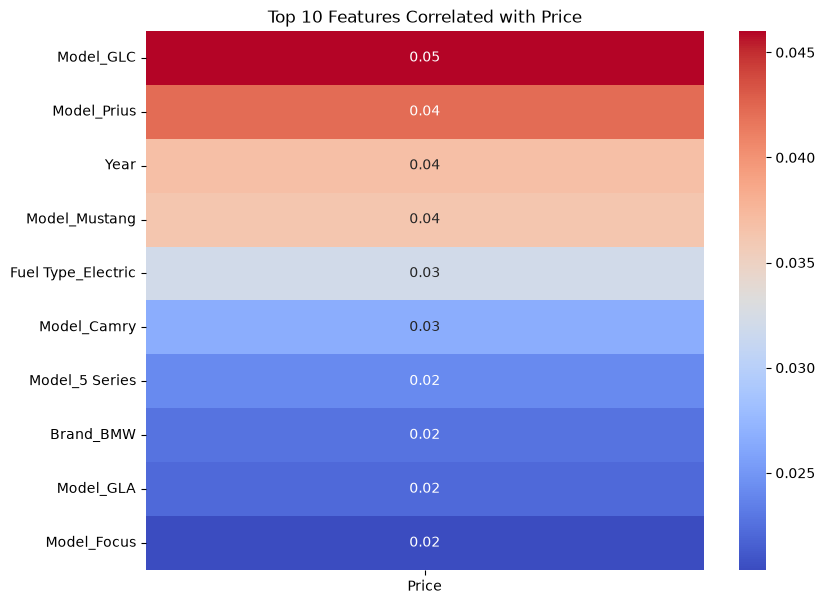

In [19]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_10.to_frame(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title(f"Top 10 Features Correlated with {'Price'}")
plt.show()

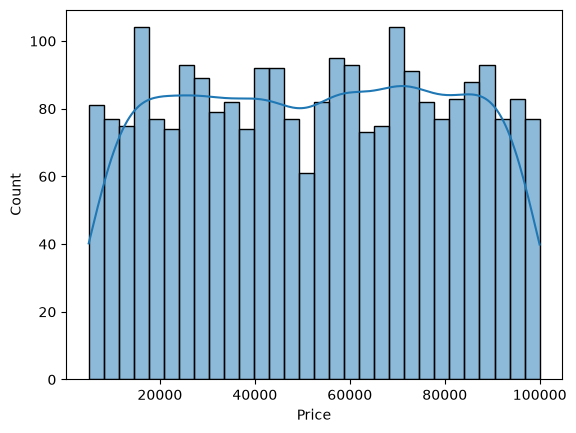

In [20]:
sns.histplot(df['Price'], bins=30, kde=True)
plt.show()

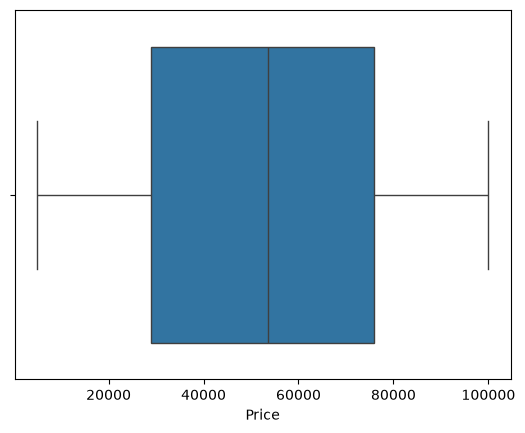

In [21]:
sns.boxplot(x='Price', data=df)
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

x=df.drop('Price', axis=1)
y=df['Price']

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_dev, x_test, y_dev, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_dev_scaled = scaler.transform(x_dev)
x_test_scaled = scaler.transform(x_test)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError 
from tensorflow.keras.callbacks import EarlyStopping


In [25]:
model=Sequential([
    Dense(128,activation='relu',input_shape=(x_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(64,activation='relu'),
    Dropout(0.1),    
    Dense(32,activation='relu'),
    Dropout(0.1),
    Dense(1,activation='linear')

])

early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=20,             
    restore_best_weights=True 
)

model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
history=model.fit(x_train_scaled, y_train, validation_data=(x_dev_scaled, y_dev), epochs=100, batch_size=32, callbacks=[early_stop])
test_loss, test_mae = model.evaluate(x_test_scaled, y_test)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3495076608.0000 - mean_absolute_error: 52494.8672 - val_loss: 3537358080.0000 - val_mean_absolute_error: 52910.4336
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3470777600.0000 - mean_absolute_error: 52259.6328 - val_loss: 3476630272.0000 - val_mean_absolute_error: 52330.2461
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3321432576.0000 - mean_absolute_error: 50816.5742 - val_loss: 3195518464.0000 - val_mean_absolute_error: 49549.9023
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2828127232.0000 - mean_absolute_error: 45739.8672 - val_loss: 2469920256.0000 - val_mean_absolute_error: 41862.7344
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1916777600.0000 - mean_absolute_error: 36075.5078 - val_loss: 1444102656.0000 - val_mean_absolute_error: 31229.8164
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1042768640.0000 - mean_absolute_error: 26805.9512 - val_loss: 8634

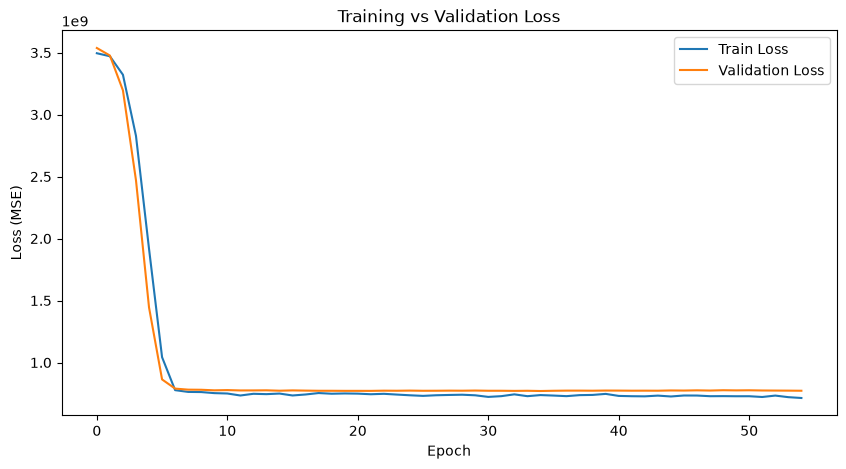

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [28]:
mean_price = y_test.mean()
error_percentage = (test_mae / mean_price) * 100

print(f"Average Price: ${mean_price:,.2f}")
print(f"Average Error (MAE): ${test_mae:,.2f}")
print(f"Error Percentage: {error_percentage:.2f}%")

Average Price: $52,911.52
Average Error (MAE): $24,209.89
Error Percentage: 45.76%


## ⚠️ Model Performance Analysis & Key Finding

### Observation
Despite a correct end-to-end pipeline (encoding, scaling with no data leakage, 
train/dev/test split, and a regularized NN with EarlyStopping), the model 
achieved a **Mean Absolute Error (MAE) of ~$24,210** on the test set, against 
an average price of ~$52,911 — an error rate of **~45.8%**. This is far above 
what would be considered acceptable for a regression model in production.

### Root Cause
Prior EDA revealed two key facts that explain this result:

1. **No meaningful correlation**: The correlation heatmap between `Price` and 
   all other features showed values close to 0, indicating no linear 
   relationship the model could learn from.
2. **Uniform target distribution**: The histogram of `Price` showed an almost 
   uniform distribution across its entire range ($0–$100,000), with no 
   skew, no concentration, and no outliers — a pattern consistent with 
   randomly generated data rather than real-world pricing, which is typically 
   influenced by measurable factors (brand, mileage, age, etc.).

### Evidence
- See correlation heatmap (Top 10 features vs. Price) — all values near 0.
- See target distribution plots (histogram + boxplot) — uniform, no skew.

### Takeaway
**A model can only learn patterns that exist in the data.** No amount of 
architecture tuning, additional layers, or hyperparameter optimization can 
compensate for a lack of real signal between features and target. This 
dataset appears to be synthetically generated with a randomized `Price` 
column, independent of the other features.

**Key lesson for future projects**: Always check feature-target correlation 
*before* investing time in model building. If there's no signal, the priority 
shifts to sourcing better data — not tuning the model.